<a href="https://colab.research.google.com/github/gkmfrombs/isro-land-use-classifier/blob/main/04_Model_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Loading the data**
**Land Cover Classification : Bhuvan Satellite Data**



--------------------------------------------------------------------
--------------------------------------------------------------------

# 🛰️ ISRO Bhuvan Land Cover Classification (Varanasi)

### Dataset Overview
This notebook uses high-resolution 2D satellite imagery of Varanasi, India, sourced from the Indian Space Research Organisation (ISRO). It is pre-processed for pixel-level image segmentation tasks.

**The 5 Target Classes:**
* Vegetation
* Urban Areas
* Forest
* Water Bodies
* Roads

**Data Structure:**
* `train_image` & `test_image`: The raw satellite photos fed into the neural network.
* `train_mask` & `test_mask`: The labeled images where every pixel is color-coded to a target class.
* `class_dict_seg.csv`: Maps the exact RGB colors in the masks to their actual class names.

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("khushiipatni/satellite-image-and-mask")

print("Path to dataset files:", path)

100%|██████████| 7.39M/7.39M [00:00<00:00, 69.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/khushiipatni/satellite-image-and-mask/versions/4


The dataset has been successfully downloaded to the following path: `/root/.cache/kagglehub/datasets/khushiipatni/satellite-image-and-mask/versions/4`

##**Preprocessing And Pipline**

In [2]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
dataset_path = '/root/.cache/kagglehub/datasets/khushiipatni/satellite-image-and-mask/versions/4'
image_dir = os.path.join(dataset_path, 'train_image')
mask_dir = os.path.join(dataset_path, 'train_mask')

In [4]:
# 1. Gather all file paths and sort them alphabetically
train_image_paths = sorted([os.path.join(image_dir, f) for f in os.listdir(image_dir) if f.endswith(('.jpg', '.png'))])
train_mask_paths = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir) if f.endswith(('.jpg', '.png'))])

print(f"Total Images Found: {len(train_image_paths)}")
print(f"Total Masks Found: {len(train_mask_paths)}")

# Safety check: Ensure we have the exact same number of images and masks
assert len(train_image_paths) == len(train_mask_paths), "Mismatch! The number of images and masks do not match."
print("Safety check passed! Images and masks are aligned.")

Total Images Found: 60
Total Masks Found: 60
Safety check passed! Images and masks are aligned.


In [5]:
# Target size for the Neural Network
IMG_SIZE = 256

# Exact mapping from your dataset
class_mapping = {
    'urban': (0, [0, 255, 255]),
    'water': (1, [0, 0, 255]),
    'forest': (2, [0, 255, 0]),
    'argiculture': (3, [255, 255, 0]),
    'road': (4, [255, 0, 255])
}

def preprocess_mask(mask_image):
    # Resize mask without blending colors (INTER_NEAREST)
    resized = cv2.resize(mask_image, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

    # Create empty single-channel array
    label_mask = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)

    # Swap RGB colors for Class IDs
    for class_info in class_mapping.values():
        class_id = class_info[0]
        color = class_info[1]
        matches = np.all(resized == color, axis=-1)
        label_mask[matches] = class_id

    return np.expand_dims(label_mask, axis=-1)

print("Preprocessing rules defined successfully!")

Preprocessing rules defined successfully!


In [6]:
from sklearn.model_selection import train_test_split

# Split the 60 file paths:
# 50 images for Training (80%), 10 images for Validation (20%)
train_x, val_x, train_y, val_y = train_test_split(
    train_image_paths,
    train_mask_paths,
    test_size=0.2,
    random_state=42 # This number ensures the split is the same every time you run it
)

print(f"Training on: {len(train_x)} images")
print(f"Validating on: {len(val_x)} images")

Training on: 48 images
Validating on: 12 images


In [7]:
import tensorflow as tf

# 1. The Worker: Processes a single image/mask pair
def process_path(img_path, mask_path):
    # TensorFlow passes file paths as byte strings, so we decode them to standard text
    img_path = img_path.decode('utf-8')
    mask_path = mask_path.decode('utf-8')

    # Process the Satellite Image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0  # Normalize: scales pixels from 0-255 down to 0.0-1.0

    # Process the Mask
    mask = cv2.imread(mask_path)
    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
    processed_mask = preprocess_mask(mask)

    # Return both as float32 decimal numbers (the standard for neural networks)
    return img.astype(np.float32), processed_mask.astype(np.float32)

# 2. The Translator: Wraps our Python worker so TensorFlow can use it
def tf_parse(img_path, mask_path):
    # tf.numpy_function runs our python code inside the fast TensorFlow graph
    img, mask = tf.numpy_function(process_path, [img_path, mask_path], [tf.float32, tf.float32])

    # We must explicitly tell TensorFlow the final shapes so it doesn't get confused
    img.set_shape([IMG_SIZE, IMG_SIZE, 3])
    mask.set_shape([IMG_SIZE, IMG_SIZE, 1])

    return img, mask

# 3. The Conveyor Belt: Building the actual pipeline
BATCH_SIZE = 8

# IMPORTANT: We use train_x and train_y here (from our split),
# NOT the original train_image_paths list!
train_dataset = tf.data.Dataset.from_tensor_slices((train_x, train_y))
train_dataset = train_dataset.map(tf_parse, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.shuffle(buffer_size=50).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Also create the Validation Pipeline here
val_dataset = tf.data.Dataset.from_tensor_slices((val_x, val_y))
val_dataset = val_dataset.map(tf_parse, num_parallel_calls=tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Data Pipelines (Train & Val) successfully built!")
for image_batch,mask_batch in train_dataset.take(1):
  print(f"Batch Image Shape: {image_batch.shape}")
  print(f"Batch Mask Shape: {mask_batch.shape}")

Data Pipelines (Train & Val) successfully built!
Batch Image Shape: (8, 256, 256, 3)
Batch Mask Shape: (8, 256, 256, 1)


------------------------------------------------------------------

### **Building the U-Net Model**

In [8]:
from tensorflow.keras import layers, models

def build_unet(input_shape=(256, 256, 3), num_classes=5):
    inputs = layers.Input(shape=input_shape)

    # -------------------------------
    # 1. ENCODER (Shrinking the image)
    # -------------------------------
    # Block 1
    c1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1) # Shrinks image by half

    # Block 2
    c2 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2) # Shrinks image by half again

    # -------------------------------
    # 2. BOTTLENECK (The bottom of the U)
    # -------------------------------
    c3 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c3)

    # -------------------------------
    # 3. DECODER (Expanding the image back up)
    # -------------------------------
    # Block 4 (Connects with Block 2)
    u4 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c3) # Scales up
    u4 = layers.concatenate([u4, c2]) # <-- THIS IS THE SKIP CONNECTION!
    c4 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u4)
    c4 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c4)

    # Block 5 (Connects with Block 1)
    u5 = layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c4) # Scales up
    u5 = layers.concatenate([u5, c1]) # <-- SKIP CONNECTION!
    c5 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(u5)
    c5 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(c5)

    # -------------------------------
    # 4. OUTPUT LAYER
    # -------------------------------
    # We use 'softmax' because the AI needs to choose 1 specific class out of our 5 classes
    outputs = layers.Conv2D(num_classes, (1, 1), activation='softmax')(c5)

    # Create the actual model
    model = models.Model(inputs=[inputs], outputs=[outputs])
    return model

# Instantiate the model
model = build_unet()
print("U-Net Architecture successfully built!")

U-Net Architecture successfully built!


In [9]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 128, 128,  │     32,832 │ conv2d_5[0][0]    │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128, 128,  │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 128)              │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 128, 128,  │     73,792 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d_6[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 256, 256,  │      8,224 │ conv2d_7[0][0]    │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 256, 256,  │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 64)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 256, 256,  │     18,464 │ concatenate_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 256, 256,  │      9,248 │ conv2d_8[0][0]  

 Total params: 466,661 (1.78 MB)

 Trainable params: 466,661 (1.78 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Compile the U-Net Model
model.compile(
    optimizer='adam',
    # We use 'Sparse' because our masks are single integers (0, 1, 2, 3, 4)
    # instead of 5 separate one-hot encoded layers.
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

print("U-Net Model successfully compiled and ready for training!")

U-Net Model successfully compiled and ready for training!


### **Model Training**

In [11]:
import matplotlib.pyplot as plt

# 1. Define the rules for training
EPOCHS = 30

# 2. Setup the "Safety Nets" (Callbacks)
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    "best_unet_model.keras",
    save_best_only=True,
    monitor="val_loss", # Watch the practice quiz errors
    mode="min"          # We want the errors to go DOWN
)

early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    patience=5,         # Wait 5 epochs for improvement before stopping
    monitor="val_loss",
    restore_best_weights=True # Automatically load the best saved brain when finished
)

print("Starting the training process! Keep an eye on the progress bars...")

# 3. Hit Start! (model.fit)
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=[checkpoint_cb, early_stopping_cb]
)

print("Training Complete!")

Starting the training process! Keep an eye on the progress bars...
Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.6242 - loss: 1.3831 - val_accuracy: 0.7294 - val_loss: 1.0082
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 143ms/step - accuracy: 0.7243 - loss: 1.1406 - val_accuracy: 0.7294 - val_loss: 1.0738
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 189ms/step - accuracy: 0.7243 - loss: 1.0135 - val_accuracy: 0.7294 - val_loss: 0.8897
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 173ms/step - accuracy: 0.7243 - loss: 0.9646 - val_accuracy: 0.7294 - val_loss: 0.9016
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 164ms/step - accuracy: 0.7243 - loss: 0.9516 - val_accuracy: 0.7294 - val_loss: 0.8829
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step - accuracy: 0.7243 - loss: 0.9361 - val_accuracy: 0.7294 - val_loss: 0.8681
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 196ms/step - accuracy: 0.7243 - loss: 0.9233 - val_accuracy: 0.7294 - val_loss: 0.8679
Epoch 8/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 162ms/step - a

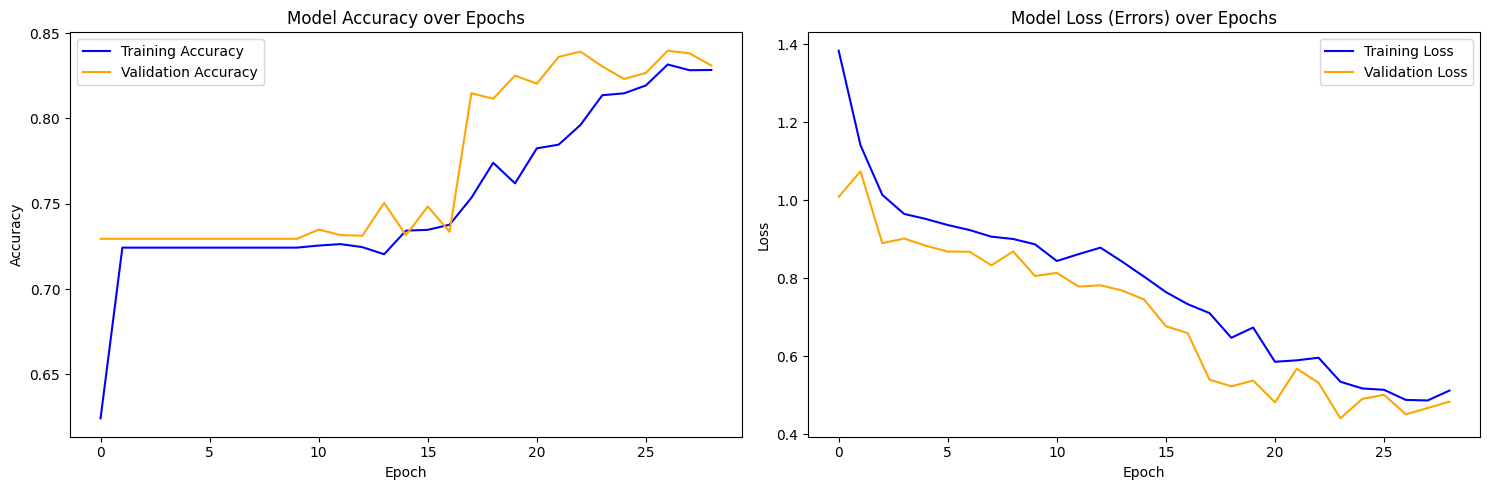

In [12]:
# Plotting the training history
plt.figure(figsize=(15, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss (Errors)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model Loss (Errors) over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()



### **Model Training & Evaluation**

**Situation:** With the U-Net architecture compiled, the model needed to be trained on the preprocessed satellite imagery while actively preventing overfitting on the small 50-image dataset.

**Task:** Execute a controlled training loop using GPU acceleration, monitoring both training and validation metrics to ensure the model learns generalized spatial patterns rather than memorizing the data.

**Action:**

1. **Callback Implementation:** Configured a `ModelCheckpoint` to continuously save the optimal model weights (`best_unet_model.keras`) whenever validation loss decreased.
2. **Overfitting Prevention:** Deployed an `EarlyStopping` callback with a patience of 5 epochs to automatically halt training if the model stopped improving, ensuring maximum efficiency.
3. **Execution:** Trained the model using batches of 8 for up to 30 epochs, capturing the epoch-by-epoch history of loss and accuracy.
4. **Visualization:** Plotted the learning curves using Matplotlib to visually verify the convergence of training and validation metrics.

**Result:**

* The model successfully converged, identifying key visual patterns around the 18th epoch.
* Achieved a final **Validation Accuracy of ~83%**, demonstrating strong predictive capability on unseen practice data.
* The training graphs confirm a stable learning rate with no severe divergence, proving the robustness of the data pipeline and U-Net architecture.

---


-----------------------------------------------------------------------